In [249]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error


---
---
---

2 Load and inspect


In [9]:
raw = pd.read_csv('data/almaty_apartments_raw.csv')
ids = raw['listing_id'].drop_duplicates().sample(frac = 0.9, random_state = 2463)
df = raw[raw['listing_id'].isin(ids)].reset_index(drop = True)

print(df.shape)
print(df.dtypes)
print(df.isna().sum())

(1154, 11)
listing_id           object
listed_date          object
district             object
rooms                object
area_m2              object
floor                 int64
total_floors          int64
year_built          float64
building_type        object
ceiling_height_m    float64
price_kzt            object
dtype: object
listing_id            0
listed_date           0
district              0
rooms                 0
area_m2               0
floor                 0
total_floors          0
year_built           57
building_type         0
ceiling_height_m    131
price_kzt             0
dtype: int64


In [13]:
print(df.describe(include="all").T)

                   count unique         top freq         mean         std  \
listing_id          1154   1080   ALM-10003    3          NaN         NaN   
listed_date         1154    246  2026-04-18   11          NaN         NaN   
district            1154     48       Medeu  144          NaN         NaN   
rooms               1154      6           2  427          NaN         NaN   
area_m2             1154    651        53.5    6          NaN         NaN   
floor             1154.0    NaN         NaN  NaN     5.829289    4.718748   
total_floors      1154.0    NaN         NaN  NaN     10.35182    6.056768   
year_built        1097.0    NaN         NaN  NaN  1944.695533  297.770827   
building_type       1154      3       panel  487          NaN         NaN   
ceiling_height_m  1023.0    NaN         NaN  NaN     2.722121    0.421468   
price_kzt           1154   1049    36060000    3          NaN         NaN   

                  min     25%     50%     75%     max  
listing_id        N

1. columns area_m2, rooms, price_kzt should be either int or float

2.

In [21]:
print('duplicated sum: ',df.duplicated().sum())
print('not exact sum: ', df.drop_duplicates()['listing_id'].duplicated().sum())

duplicated sum:  33
not exact sum:  41


In [53]:
df[df['listing_id'].duplicated(keep = False)].sort_values(by='listing_id')

,listing_id,listed_date,district,rooms,area_m2,floor,total_floors,year_built,building_type,ceiling_height_m,price_kzt
7,ALM-10003,2026-05-29,Auezov,2,48.6,2,5,1978.0,panel,2.55,26120000
962,ALM-10003,2026-05-04,Auezov,2,48.6,2,5,1978.0,panel,2.55,28320000
818,ALM-10003,2026-05-29,Auezov,2,48.6,2,5,1978.0,panel,2.55,26120000
935,ALM-10009,2025-12-03,Medeuskiy,1,33.4,2,9,1992.0,brick,3.19,42700000
177,ALM-10009,2026-01-19,Medeuskiy,1,33.4,2,9,1992.0,brick,3.19,39400000
...,...,...,...,...,...,...,...,...,...,...,...
191,ALM-11124,2026-04-01,Nauryzbay,2,49.4,5,12,1964.0,panel,NaN,18680000
1089,ALM-11124,2026-03-18,Nauryzbay,2,49.4,5,12,1964.0,panel,NaN,19580000
158,ALM-11147,2026-06-25,Almaly,2,56.7,4,9,2018.0,monolith,2.86,57130000
170,ALM-11147,2026-05-26,Almaly,2,56.7,4,9,2018.0,monolith,2.86,59610000


3.
listing_id           **string**

listed_date          **object**

district             **category**

rooms                **int64**

area_m2              **float64**

floor                 **int64**

total_floors          **int64**

year_built          **int64**

building_type        **category**

ceiling_height_m    **float64**

price_kzt            **float64**

---
---
---

3a · Duplicates and reposts (2 pts)

In [122]:
df['listed_date'] = df['listed_date'].astype('datetime64[ns]')
df['district'] = df['district'].astype('str') #later making it category

df['rooms'] = df['rooms'].replace({'studio': 1})
df['rooms'] = df['rooms'].astype('int64')

df['area_m2'] = (df['area_m2'].astype(str)
                .str.replace('. ', '', regex=False)
                .str.replace(',', '.', regex=False)
                .str.replace('m²', '', regex=False))
df['area_m2'] = df['area_m2'].astype('float64')

df['building_type'] = df['building_type'].astype('category')

df['price_kzt'] = (df['price_kzt'].astype(str)
                    .str.replace(',', '', regex=False)
                    .str.replace(' ', '', regex=False)
                    .str.replace('.', '', regex=False)
                    .str.replace(' ₸', '', regex=False))
df['price_kzt'] = df['price_kzt'].astype('float64')
df['price_kzt'] = pd.to_numeric(df['price_kzt'], errors='coerce')

changed dtypes of each row

now creating new df where i delete dublicates in apartments (because there's different prices and i prefer to keep the ones, that are recent)

In [76]:
df_dublicates = df.sort_values('listed_date', ascending=True)
df_dublicates = df_dublicates.drop_duplicates(subset=['listing_id'], keep = "last")

In [ ]:
df_dublicates['district'] = df_dublicates['district'].str.strip().str.title()

district_mapping = {
    'Алатауский': 'Alatau',
    'Alatauskiy': 'Alatau',
    'Алмалинский': 'Almaly',
    'Almalinskiy': 'Almaly',
    'Ауэзовский': 'Auezov',
    'Auezovskiy': 'Auezov',
    'Бостандыкский': 'Bostandyk',
    'Bostandykskiy': 'Bostandyk',
    'Медеуский': 'Medeu',
    'Medeuskiy': 'Medeu',
    'Наурызбайский': 'Nauryzbay',
    'Nauryzbayskiy': 'Nauryzbay',
    'Турксибский': 'Turksib',
    'Turksibskiy': 'Turksib',
    'Жетысуский': 'Zhetysu',
    'Zhetysuskiy': 'Zhetysu'
}
df_dublicates['district'] = df_dublicates['district'].replace(district_mapping)
df_dublicates['district'] = df_dublicates['district'].astype('category')

In [107]:
print(f'new number of categories in district: {df_dublicates["district"].nunique()}')
print('\n', df_dublicates.dtypes)

new number of categories in district: 8

 listing_id                  object
listed_date         datetime64[ns]
district                  category
rooms                        int64
area_m2                    float64
floor                        int64
total_floors                 int64
year_built                 float64
building_type             category
ceiling_height_m           float64
price_kzt                  float64
dtype: object


---

4 Sentinels, impossible values, outliers


In [128]:
df_dublicates.describe()

,listed_date,rooms,area_m2,floor,total_floors,year_built,ceiling_height_m,price_kzt
count,1080,1080.000000,1080.000000,1080.000000,1080.000000,1025.000000,957.000000,1.080000e+03
mean,2026-05-01 13:54:40,2.253704,68.530185,5.826852,10.358333,1943.233171,2.719049,4.618403e+07
min,2026-01-01 00:00:00,1.000000,25.300000,-1.000000,3.000000,0.000000,0.000000,1.221000e+07
25%,2026-03-05 00:00:00,1.000000,44.800000,2.000000,5.000000,1972.000000,2.620000,2.791250e+07
50%,2026-05-01 00:00:00,2.000000,58.500000,5.000000,9.000000,1986.000000,2.770000,3.976000e+07
75%,2026-06-29 00:00:00,3.000000,79.425000,8.000000,12.000000,2009.000000,2.910000,5.738500e+07
max,2026-08-31 00:00:00,5.000000,736.000000,30.000000,25.000000,2024.000000,3.200000,1.930000e+08
std,NaN,1.013571,56.502851,4.731789,6.103701,301.690652,0.433422,2.527024e+07


In [138]:
print((df_dublicates['floor'] == -1).sum())
print((df_dublicates['year_built'] == 0).sum())
print((df_dublicates['ceiling_height_m'] == 0).sum())

10
24
20


clear anomalies are in floor(-1), year_built(0), ceiling_height_m(0)
total floors < floor

1.

In [145]:
df_dublicates['floor']= df_dublicates['floor'].replace(-1, np.nan)
df_dublicates['year_built']= df_dublicates['year_built'].replace(0, np.nan)
df_dublicates['ceiling_height_m'] =df_dublicates['ceiling_height_m'].replace(0, np.nan)


2.

In [162]:
mask = df_dublicates['floor'] > df_dublicates['total_floors']
df_dublicates[mask][['listing_id','building_type', 'floor', 'total_floors']]


,listing_id,building_type,floor,total_floors
853,ALM-10729,panel,15.0,12
742,ALM-10851,panel,13.0,12
1059,ALM-10944,brick,4.0,3
661,ALM-10044,monolith,30.0,25
229,ALM-10420,panel,11.0,9
1116,ALM-10636,panel,6.0,5
677,ALM-10628,brick,6.0,5
124,ALM-10881,panel,8.0,5
202,ALM-10074,monolith,11.0,9
729,ALM-10695,panel,14.0,12


In [163]:
df_dublicates.loc[mask, 'floor'] = np.nan

we don't know wheter it's a mistake inside of "floor" or inside of "total_floors", so we need to handle them.
we have only 10 apartments like that, but i don't want delete them. 
instead, i'd like to put Nan into floor section

3.

In [174]:
df_dublicates["price_per_m2"] = df_dublicates["price_kzt"] / df_dublicates["area_m2"]
df_dublicates["area_before_fix"] = df_dublicates["area_m2"]

In [204]:
q1 = df_dublicates["price_per_m2"].quantile(0.25)
q3 = df_dublicates["price_per_m2"].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5*iqr
high = q3 + 1.5*iqr

mask_outliers = (df_dublicates["price_per_m2"] < low) | (df_dublicates["price_per_m2"] > high)
print('n of outliers in general', mask_outliers.sum())

n of outliers in general 0


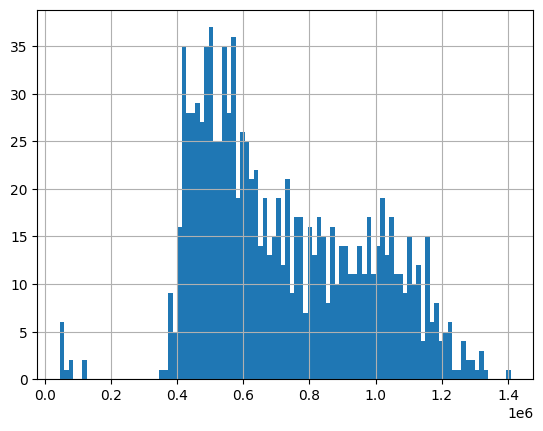

In [198]:
df_dublicates["price_per_m2"].hist(bins=100)
plt.show()

clearly requieres grouping 

In [221]:
def fences(values, groups = None):
    if groups is None:
        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
    else:
        grouped = values.groupby(groups, observed = True)
        q1_group = grouped.quantile(0.25)
        q3_group = grouped.quantile(0.75)
        
        q1 = groups.map(q1_group).astype(float)
        q3 = groups.map(q3_group).astype(float)
    
    iqr = q3 - q1
    return q1-(1.5*iqr), q3+(1.5*iqr)

low, high = fences(df_dublicates["price_per_m2"], df_dublicates["district"])
mask_outliers = (df_dublicates["price_per_m2"] < low) | (df_dublicates["price_per_m2"] > high)

print(df_dublicates.loc[mask_outliers])
print('n of outliers after grouping by district: ', mask_outliers.sum())

     listing_id listed_date   district  rooms  area_m2  floor  total_floors  \
894   ALM-10910  2026-01-01    Zhetysu      3    736.0    3.0            20   
984   ALM-10276  2026-02-06    Turksib      2    604.0   15.0            16   
569   ALM-10405  2026-02-10    Turksib      1    356.0    5.0             5   
1073  ALM-11122  2026-02-17    Zhetysu      2    647.0    4.0            12   
296   ALM-10072  2026-03-01      Medeu      2    530.0    9.0            20   
960   ALM-10058  2026-03-15  Bostandyk      2    555.0    4.0            12   
750   ALM-10921  2026-04-22    Zhetysu      3    668.0    5.0             5   
47    ALM-10264  2026-05-27  Bostandyk      1    495.0    3.0             5   
901   ALM-10909  2026-06-18     Alatau      2    565.0    7.0            16   
319   ALM-10605  2026-07-05  Nauryzbay      2     54.3    5.0            20   
176   ALM-10069  2026-08-11    Zhetysu      2    481.0    3.0             5   
601   ALM-10659  2026-08-24    Turksib      2    544

we can see that theres some weird area_m2 values, that are fittable if we /10 them

In [236]:
mask_area = df_dublicates['area_m2'] > 100
suspects = df_dublicates[mask_outliers & mask_area].copy()

suspects['area_m2'] = suspects['area_m2'] / 10

In [237]:
df_dublicates.update(suspects[['area_m2']])
df_clean = df_dublicates.copy()

In [241]:
print(df_clean.loc[mask_outliers])


     listing_id listed_date   district  rooms  area_m2  floor  total_floors  \
894   ALM-10910  2026-01-01    Zhetysu      3     73.6    3.0            20   
984   ALM-10276  2026-02-06    Turksib      2     60.4   15.0            16   
569   ALM-10405  2026-02-10    Turksib      1     35.6    5.0             5   
1073  ALM-11122  2026-02-17    Zhetysu      2     64.7    4.0            12   
296   ALM-10072  2026-03-01      Medeu      2     53.0    9.0            20   
960   ALM-10058  2026-03-15  Bostandyk      2     55.5    4.0            12   
750   ALM-10921  2026-04-22    Zhetysu      3     66.8    5.0             5   
47    ALM-10264  2026-05-27  Bostandyk      1     49.5    3.0             5   
901   ALM-10909  2026-06-18     Alatau      2     56.5    7.0            16   
319   ALM-10605  2026-07-05  Nauryzbay      2     54.3    5.0            20   
176   ALM-10069  2026-08-11    Zhetysu      2     48.1    3.0             5   
601   ALM-10659  2026-08-24    Turksib      2     54

---
---
---

5 Missing data


5a

In [243]:
NUMERIC = ["rooms", "area_m2", "floor", "total_floors", "year_built", "ceiling_height_m"]

train, test = train_test_split(df_clean, test_size=0.2, random_state = 2463)
train, test = train.copy(), test.copy()

print(train[NUMERIC].isna().sum())

rooms                 0
area_m2               0
floor                15
total_floors          0
year_built           65
ceiling_height_m    120
dtype: int64


5b

In [247]:
rate = train.assign(missing=train["ceiling_height_m"].isna()).groupby("building_type", observed = True)["missing"].mean()
print(rate)

building_type
brick       0.151111
monolith    0.029091
panel       0.214286
Name: missing, dtype: float64


brick - 15%
monolith - 2%
panel - 21%

this is clearly MAR

In [248]:
rate = train.assign(missing=train["year_built"].isna()).groupby("building_type", observed = True)["missing"].mean()
print(rate)

building_type
brick       0.080000
monolith    0.072727
panel       0.074176
Name: missing, dtype: float64


brick - 8%
monolith - 7%
panel - 8%

here, i think this has MCAR rather than MAR

5c

In [251]:
known = train[train["ceiling_height_m"].notna()]
hidden = known.sample(frac=0.15, random_state=2463).index

rest = train.drop(index=hidden)                   
answers = train.loc[hidden, "ceiling_height_m"]   

print(len(hidden), "values hidden")

112 values hidden


In [263]:
pred_global = rest["ceiling_height_m"].median()
mae_global = mean_absolute_error(answers, [pred_global]*len(answers))

med_by_group = rest.groupby("building_type", observed = True)["ceiling_height_m"].median()
pred_grouped = train.loc[hidden, "building_type"].map(med_by_group)
mae_grouped = mean_absolute_error(answers, pred_grouped)

print(f'{mae_global:.5f}\n{mae_grouped:.5f}')

0.14277
0.07036


we need to prefer second variant, because the error is only 7%

5d

In [ ]:
med_by_group = train.groupby("building_type")["ceiling_height_m"].median()


train["ceiling_height_m"] = train["ceiling_height_m"].fillna(train["building_type"].map(med_by_group))
test["ceiling_height_m"] = test["ceiling_height_m"].fillna(test["building_type"].map(med_by_group))

print(train[NUMERIC].isna().sum())
print(test[NUMERIC].isna().sum())

float64
float64
building_type
brick       2.93
monolith    2.85
panel       2.60
Name: ceiling_height_m, dtype: float64


C:\Users\Ashim\AppData\Local\Temp\ipykernel_13076\3357765947.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  med_by_group = train.groupby("building_type")["ceiling_height_m"].median()


AssertionError: Something has gone wrong, please report a bug at https://github.com/pandas-dev/pandas/issues

In [273]:

print(med_by_group)  # проверьте, нет ли там NaN для какой-то группы

building_type
brick       2.93
monolith    2.85
panel       2.60
Name: ceiling_height_m, dtype: float64
